# 1. Import Data

In [1]:
import pandas as pd

df = pd.read_csv("BigMart Sales Data.csv")
df

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976


In [2]:
# Simpan kondisi awal dataset untuk laporan akhir
raw_missing = df.isnull().sum().sum()
raw_duplicates = df.duplicated().sum()
raw_columns = df.shape[1]
raw_head = df.head(2).copy() # Ambil contoh data mentah

In [3]:
data_copy = df.copy()
data_copy

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976


# 2. Data Exploration

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [5]:
df.duplicated().sum()

0

In [6]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [7]:
df.dtypes

Item_Identifier               object
Item_Weight                  float64
Item_Fat_Content              object
Item_Visibility              float64
Item_Type                     object
Item_MRP                     float64
Outlet_Identifier             object
Outlet_Establishment_Year      int64
Outlet_Size                   object
Outlet_Location_Type          object
Outlet_Type                   object
Item_Outlet_Sales            float64
dtype: object

In [8]:
# cek jumlah missing values per kolom

df.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [9]:
df.isnull().values.any()

True

In [10]:
# persentase missing values
 
(df.isnull().sum()/len(df))*100

Item_Identifier               0.000000
Item_Weight                  17.165317
Item_Fat_Content              0.000000
Item_Visibility               0.000000
Item_Type                     0.000000
Item_MRP                      0.000000
Outlet_Identifier             0.000000
Outlet_Establishment_Year     0.000000
Outlet_Size                  28.276428
Outlet_Location_Type          0.000000
Outlet_Type                   0.000000
Item_Outlet_Sales             0.000000
dtype: float64

In [11]:
# tampilkan baris yang punya missing values 

df[df.isnull().any(axis=1)]

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
7,FDP10,NaN,Low Fat,0.127470,Snack Foods,107.7622,OUT027,1985,Medium,Tier 3,Supermarket Type3,4022.7636
8,FDH17,16.20,Regular,0.016687,Frozen Foods,96.9726,OUT045,2002,NaN,Tier 2,Supermarket Type1,1076.5986
9,FDU28,19.20,Regular,0.094450,Frozen Foods,187.8214,OUT017,2007,NaN,Tier 2,Supermarket Type1,4710.5350
18,DRI11,NaN,Low Fat,0.034238,Hard Drinks,113.2834,OUT027,1985,Medium,Tier 3,Supermarket Type3,2303.6680
...,...,...,...,...,...,...,...,...,...,...,...,...
8504,NCN18,NaN,Low Fat,0.124111,Household,111.7544,OUT027,1985,Medium,Tier 3,Supermarket Type3,4138.6128
8508,FDW31,11.35,Regular,0.043246,Fruits and Vegetables,199.4742,OUT045,2002,NaN,Tier 2,Supermarket Type1,2587.9646
8509,FDG45,8.10,Low Fat,0.214306,Fruits and Vegetables,213.9902,OUT010,1998,NaN,Tier 3,Grocery Store,424.7804
8514,FDA01,15.00,Regular,0.054489,Canned,57.5904,OUT045,2002,NaN,Tier 2,Supermarket Type1,468.7232


# Cek typo pada kolom yang bertipe data kategorikal

In [12]:
# cek typo 
# Melihat distribusi frekuensi pada kolom kategori

print(df['Item_Identifier'].value_counts())

FDW13    10
FDG33    10
NCY18     9
FDD38     9
DRE49     9
         ..
FDY43     1
FDQ60     1
FDO33     1
DRF48     1
FDC23     1
Name: Item_Identifier, Length: 1559, dtype: int64


In [13]:
df[df["Item_Weight"].isnull()]["Item_Identifier"].value_counts()

FDK08    2
FDA08    2
FDV23    2
FDY56    2
FDI04    2
        ..
FDM44    1
FDZ48    1
FDK41    1
FDD57    1
NCN18    1
Name: Item_Identifier, Length: 1142, dtype: int64

In [14]:
df[df["Item_Identifier"] == "FDP10"]

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
7,FDP10,NaN,Low Fat,0.127470,Snack Foods,107.7622,OUT027,1985,Medium,Tier 3,Supermarket Type3,4022.7636
585,FDP10,19.0,Low Fat,0.128066,Snack Foods,104.3622,OUT035,2004,Small,Tier 2,Supermarket Type1,1905.5196
2623,FDP10,19.0,Low Fat,0.128815,Snack Foods,107.6622,OUT017,2007,NaN,Tier 2,Supermarket Type1,1164.4842
3382,FDP10,19.0,Low Fat,0.128289,Snack Foods,104.9622,OUT049,1999,Medium,Tier 1,Supermarket Type1,1164.4842
4585,FDP10,19.0,Low Fat,0.128090,Snack Foods,107.0622,OUT046,1997,Small,Tier 1,Supermarket Type1,1376.2086
6087,FDP10,19.0,Low Fat,0.128350,Snack Foods,106.5622,OUT045,2002,NaN,Tier 2,Supermarket Type1,1482.0708
7883,FDP10,19.0,Low Fat,0.127984,Snack Foods,107.6622,OUT013,1987,High,Tier 3,Supermarket Type1,1270.3464


In [15]:
df[df["Item_Identifier"] == "DRC01"]

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2272,DRC01,5.92,Regular,0.019309,Soft Drinks,49.0692,OUT017,2007,NaN,Tier 2,Supermarket Type1,1478.0760
2927,DRC01,NaN,Regular,0.019107,Soft Drinks,48.4692,OUT027,1985,Medium,Tier 3,Supermarket Type3,1034.6532
5029,DRC01,5.92,Regular,0.019239,Soft Drinks,49.8692,OUT045,2002,NaN,Tier 2,Supermarket Type1,1133.1916
5077,DRC01,5.92,Regular,0.019200,Soft Drinks,47.7692,OUT046,1997,Small,Tier 1,Supermarket Type1,492.6920
5218,DRC01,5.92,Regular,0.019184,Soft Drinks,50.3692,OUT013,1987,High,Tier 3,Supermarket Type1,591.2304


In [16]:
df[df["Item_Identifier"] == "FDN52"]

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
927,FDN52,NaN,Regular,0.130933,Frozen Foods,86.9198,OUT027,1985,Medium,Tier 3,Supermarket Type3,1569.9564


In [17]:
df[df["Item_Identifier"] == "FDK57"]

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
1922,FDK57,NaN,Low Fat,0.079904,Snack Foods,120.044,OUT027,1985,Medium,Tier 3,Supermarket Type3,4434.228


In [18]:
df[df["Item_Identifier"] == "FDE52"]

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
4187,FDE52,NaN,Regular,0.029742,Dairy,88.9514,OUT027,1985,Medium,Tier 3,Supermarket Type3,3453.5046


In [19]:
df[df["Item_Identifier"] == "FDQ60"]

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
5022,FDQ60,NaN,Regular,0.191501,Baking Goods,121.2098,OUT019,1985,Small,Tier 1,Grocery Store,120.5098


In [20]:
# nanti di samakan menjadi Low Fat
# di samakan menjadi Reguler

print(df['Item_Fat_Content'].value_counts())

Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: Item_Fat_Content, dtype: int64


In [21]:
print(df['Item_Type'].value_counts())

Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: Item_Type, dtype: int64


In [22]:
print(df['Outlet_Identifier'].value_counts())

OUT027    935
OUT013    932
OUT049    930
OUT046    930
OUT035    930
OUT045    929
OUT018    928
OUT017    926
OUT010    555
OUT019    528
Name: Outlet_Identifier, dtype: int64


In [23]:
# Mencari data yang Item_Visibility-nya nol
visibilitas_nol = data_copy[data_copy['Item_Visibility'] == 0]

# Tampilkan berapa banyak baris yang nol dan contoh datanya
print(f"Jumlah baris dengan visibilitas 0: {len(visibilitas_nol)}")
display(visibilitas_nol[['Item_Identifier', 'Item_Type', 'Item_Visibility']].head())

Jumlah baris dengan visibilitas 0: 526


,Item_Identifier,Item_Type,Item_Visibility
3,FDX07,Fruits and Vegetables,0.0
4,NCD19,Household,0.0
5,FDP36,Baking Goods,0.0
10,FDY07,Fruits and Vegetables,0.0
32,FDP33,Snack Foods,0.0


In [24]:
print(df['Outlet_Size'].value_counts())

Medium    2793
Small     2388
High       932
Name: Outlet_Size, dtype: int64


In [25]:
df[df["Outlet_Identifier"] == "OUT049"]

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
10,FDY07,11.800,Low Fat,0.000000,Fruits and Vegetables,45.5402,OUT049,1999,Medium,Tier 1,Supermarket Type1,1516.0266
12,FDX32,15.100,Regular,0.100014,Fruits and Vegetables,145.4786,OUT049,1999,Medium,Tier 1,Supermarket Type1,1589.2646
17,FDP49,9.000,Regular,0.069196,Breakfast,54.3614,OUT049,1999,Medium,Tier 1,Supermarket Type1,718.3982
...,...,...,...,...,...,...,...,...,...,...,...,...
8451,FDK21,7.905,Low Fat,0.010028,Snack Foods,249.6408,OUT049,1999,Medium,Tier 1,Supermarket Type1,3254.4304
8467,FDV31,9.800,LF,0.000000,Fruits and Vegetables,175.2370,OUT049,1999,Medium,Tier 1,Supermarket Type1,3881.6140
8470,FDW27,5.860,Regular,0.151088,Meat,155.1314,OUT049,1999,Medium,Tier 1,Supermarket Type1,1551.3140
8475,NCS17,18.600,Low Fat,0.080627,Health and Hygiene,92.5436,OUT049,1999,Medium,Tier 1,Supermarket Type1,378.1744


In [26]:
# Melihat hubungan antara ID outlet dan ukurannya secara keseluruhan
display(pd.crosstab(df['Outlet_Identifier'], df['Outlet_Size']))

Outlet_Size,High,Medium,Small
Outlet_Identifier,,,
OUT013,932,0,0
OUT018,0,928,0
OUT019,0,0,528
OUT027,0,935,0
OUT035,0,0,930
OUT046,0,0,930
OUT049,0,930,0


In [27]:
# Melihat hubungan antara tipe outlet dan ukurannya secara keseluruhan
display(pd.crosstab(df['Outlet_Type'], df['Outlet_Size']))

Outlet_Size,High,Medium,Small
Outlet_Type,,,
Grocery Store,0,0,528
Supermarket Type1,932,930,1860
Supermarket Type2,0,928,0
Supermarket Type3,0,935,0


In [28]:
# Menampilkan semua kolom untuk baris yang Outlet_Size-nya missing value
tabel_lengkap_missing = data_copy[data_copy['Outlet_Size'].isnull()]

# Menampilkan tabel
display(tabel_lengkap_missing)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
8,FDH17,16.200,Regular,0.016687,Frozen Foods,96.9726,OUT045,2002,NaN,Tier 2,Supermarket Type1,1076.5986
9,FDU28,19.200,Regular,0.094450,Frozen Foods,187.8214,OUT017,2007,NaN,Tier 2,Supermarket Type1,4710.5350
25,NCD06,13.000,Low Fat,0.099887,Household,45.9060,OUT017,2007,NaN,Tier 2,Supermarket Type1,838.9080
28,FDE51,5.925,Regular,0.161467,Dairy,45.5086,OUT010,1998,NaN,Tier 3,Grocery Store,178.4344
...,...,...,...,...,...,...,...,...,...,...,...,...
8502,NCH43,8.420,Low Fat,0.070712,Household,216.4192,OUT045,2002,NaN,Tier 2,Supermarket Type1,3020.0688
8508,FDW31,11.350,Regular,0.043246,Fruits and Vegetables,199.4742,OUT045,2002,NaN,Tier 2,Supermarket Type1,2587.9646
8509,FDG45,8.100,Low Fat,0.214306,Fruits and Vegetables,213.9902,OUT010,1998,NaN,Tier 3,Grocery Store,424.7804
8514,FDA01,15.000,Regular,0.054489,Canned,57.5904,OUT045,2002,NaN,Tier 2,Supermarket Type1,468.7232


In [29]:
# 1. Kita filter data yang Outlet_Size-nya kosong (NaN)
data_kosong = data_copy[data_copy['Outlet_Size'].isnull()]

# 2. Kita hitung berapa banyak NaN di setiap kombinasi Tipe dan Lokasi
bukti_tabel = data_kosong.groupby(['Outlet_Type', 'Outlet_Location_Type']).size().reset_index(name='Jumlah_Missing')

# 3. Tampilkan hasilnya
display(bukti_tabel)

,Outlet_Type,Outlet_Location_Type,Jumlah_Missing
0,Grocery Store,Tier 3,555
1,Supermarket Type1,Tier 2,1855


In [30]:
# Mengelompokkan Tipe dan lokasinya
sebaran_lokasi = data_copy.groupby(['Outlet_Type', 'Outlet_Location_Type']).size().reset_index(name='Jumlah_Toko')
display(sebaran_lokasi)

,Outlet_Type,Outlet_Location_Type,Jumlah_Toko
0,Grocery Store,Tier 1,528
1,Grocery Store,Tier 3,555
2,Supermarket Type1,Tier 1,1860
3,Supermarket Type1,Tier 2,2785
4,Supermarket Type1,Tier 3,932
5,Supermarket Type2,Tier 3,928
6,Supermarket Type3,Tier 3,935


In [31]:
print(df['Outlet_Location_Type'].value_counts())

Tier 3    3350
Tier 2    2785
Tier 1    2388
Name: Outlet_Location_Type, dtype: int64


In [32]:
# Cek outlet tertentu yang tadinya sering kosong

display(df[df["Outlet_Identifier"] == "OUT045"][["Outlet_Identifier", "Outlet_Type", "Outlet_Size"]].head())

,Outlet_Identifier,Outlet_Type,Outlet_Size
8,OUT045,Supermarket Type1,NaN
33,OUT045,Supermarket Type1,NaN
46,OUT045,Supermarket Type1,NaN
47,OUT045,Supermarket Type1,NaN
56,OUT045,Supermarket Type1,NaN


In [33]:
print(df['Outlet_Type'].value_counts())

Supermarket Type1    5577
Grocery Store        1083
Supermarket Type3     935
Supermarket Type2     928
Name: Outlet_Type, dtype: int64


# Distribusi data

In [34]:
# UNTUK OUTLIERS DAN DISTRIBUSI DATA NORMAL/TIDAK NORMAL, SETELAH DATA CLEANING

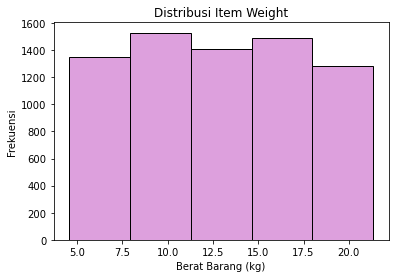

In [35]:
import matplotlib.pyplot as plt

# Memastikan data kosong dibuang agar tidak error saat plotting
# bins=5 akan membagi data berat ke dalam 5 kelompok besar
plt.hist(df['Item_Weight'], bins=5, color='plum', edgecolor='black')

plt.title("Distribusi Item Weight")
plt.xlabel("Berat Barang (kg)")
plt.ylabel("Frekuensi")
plt.show()

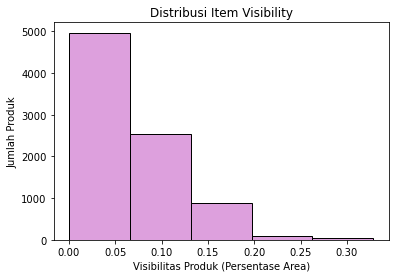

In [36]:
import matplotlib.pyplot as plt

plt.hist(df['Item_Visibility'], bins=5, color='plum', edgecolor='black')

plt.title("Distribusi Item Visibility")
plt.xlabel("Visibilitas Produk (Persentase Area)")
plt.ylabel("Jumlah Produk")
plt.show()

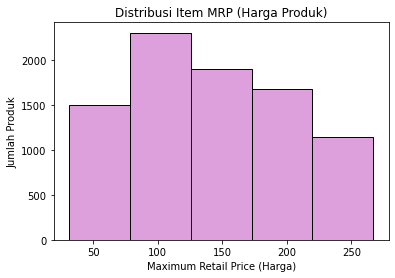

In [37]:
import matplotlib.pyplot as plt

plt.hist(df['Item_MRP'], bins=5, color='plum', edgecolor='black')

plt.title("Distribusi Item MRP (Harga Produk)")
plt.xlabel("Maximum Retail Price (Harga)")
plt.ylabel("Jumlah Produk")
plt.show()

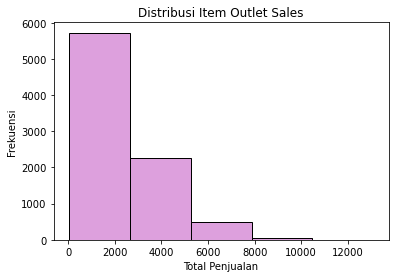

In [38]:
import matplotlib.pyplot as plt

plt.hist(df['Item_Outlet_Sales'], bins=5, color='plum', edgecolor='black')

plt.title("Distribusi Item Outlet Sales")
plt.xlabel("Total Penjualan")
plt.ylabel("Frekuensi")
plt.show()

# 3. Data Cleaning

# Input missing value Item_Weight

In [39]:
# Isi data kosong berdasarkan mean ID Produk

data_copy['Item_Weight'] = data_copy['Item_Weight'].fillna(data_copy.groupby('Item_Identifier')['Item_Weight'].transform('mean'))
print(data_copy[['Item_Identifier', 'Item_Weight']].head(20))

   Item_Identifier  Item_Weight
0            FDA15        9.300
1            DRC01        5.920
2            FDN15       17.500
3            FDX07       19.200
4            NCD19        8.930
5            FDP36       10.395
6            FDO10       13.650
7            FDP10       19.000
8            FDH17       16.200
9            FDU28       19.200
10           FDY07       11.800
11           FDA03       18.500
12           FDX32       15.100
13           FDS46       17.600
14           FDF32       16.350
15           FDP49        9.000
16           NCB42       11.800
17           FDP49        9.000
18           DRI11        8.260
19           FDU02       13.350


In [40]:
# cek apakah semua missing value pada Item Weight sudah terisi
# Ternyata ada 4 yang belum terisi

print(data_copy['Item_Weight'].isnull().sum()) 

4


In [41]:
# cek ID mana saja yang tidak terinput missing value nya

data_copy[data_copy['Item_Weight'].isnull()]['Item_Identifier'].unique()

array(['FDN52', 'FDK57', 'FDE52', 'FDQ60'], dtype=object)

In [42]:
# pada ID yang missing value nya tidak terisi
# memang tidak ada yang bisa di input karena memang data beratnya yang tidak tersedia untuk produk tersebut.

print(data_copy['Item_Identifier'].isnull().sum())

0


In [43]:
# Daftar ID yang ingin diberikan angka 0
id_target = ['FDN52', 'FDK57', 'FDE52', 'FDQ60']

# Mengisi angka 0 hanya untuk ID yang ditentukan
data_copy.loc[df['Item_Identifier'].isin(id_target), 'Item_Weight'] = 0

In [44]:
# Daftar 4 ID yang diisi angka 0
id_target = ['FDN52', 'FDK57', 'FDE52', 'FDQ60']

# Menampilkan tabel ringkasan untuk 4 ID tersebut
hasil_cek = data_copy[data_copy['Item_Identifier'].isin(id_target)][['Item_Identifier', 'Item_Weight']].drop_duplicates()
display(hasil_cek)

,Item_Identifier,Item_Weight
927,FDN52,0.0
1922,FDK57,0.0
4187,FDE52,0.0
5022,FDQ60,0.0


In [45]:
# Cek total missing values untuk seluruh kolom di dataset
print("Ringkasan Missing Values Setelah Imputasi:")
display(data_copy.isnull().sum())

Ringkasan Missing Values Setelah Imputasi:


Item_Identifier                 0
Item_Weight                     0
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

# Input missing value Outlet_Size

In [46]:
import numpy as np
import pandas as pd

# 1. Fungsi 'aman' untuk mengambil modus agar tidak IndexError
def get_mode(x):
    m = x.mode()
    return m.iloc[0] if not m.empty else np.nan

# # 2. Cek Kondisi Awal
# #print("1. KONDISI AWAL (MISSING VALUES)")
# #print(data_copy[['Outlet_Type', 'Outlet_Location_Type', 'Outlet_Size']].isnull().sum())
# #print("-" * 30)

data_copy.head(15)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
5,FDP36,10.395,Regular,0.000000,Baking Goods,51.4008,OUT018,2009,Medium,Tier 3,Supermarket Type2,556.6088
6,FDO10,13.650,Regular,0.012741,Snack Foods,57.6588,OUT013,1987,High,Tier 3,Supermarket Type1,343.5528
7,FDP10,19.000,Low Fat,0.127470,Snack Foods,107.7622,OUT027,1985,Medium,Tier 3,Supermarket Type3,4022.7636
8,FDH17,16.200,Regular,0.016687,Frozen Foods,96.9726,OUT045,2002,NaN,Tier 2,Supermarket Type1,1076.5986
9,FDU28,19.200,Regular,0.094450,Frozen Foods,187.8214,OUT017,2007,NaN,Tier 2,Supermarket Type1,4710.5350


In [47]:
# 1. AKTIFKAN LAGI: Isi berdasarkan Grup (Paling Akurat)
data_copy['Outlet_Size'] = data_copy['Outlet_Size'].fillna(
    data_copy.groupby(['Outlet_Type', 'Outlet_Location_Type'])['Outlet_Size'].transform(get_mode)
)

# 2. SAPU BERSIH: Untuk Grocery Store Tier 3 yang modusnya memang tidak ada
data_copy['Outlet_Size'] = data_copy['Outlet_Size'].fillna('Small')

# 3. CEK HASILNYA
print("Sisa Missing Value:", data_copy['Outlet_Size'].isnull().sum())

Sisa Missing Value: 0


In [48]:
# Cek proporsi setelah diisi
print(data_copy['Outlet_Size'].value_counts(normalize=True))

Small     0.562947
Medium    0.327702
High      0.109351
Name: Outlet_Size, dtype: float64


# Konsistensi Data 

In [49]:
# Mengganti semua variasi penulisan ke format standar
data_copy['Item_Fat_Content'] = data_copy['Item_Fat_Content'].replace({
    'LF': 'Low Fat',
    'low fat': 'Low Fat',
    'reg': 'Regular'
})

# Cek hasil akhir
print("Hasil setelah dibersihkan:")
print(data_copy['Item_Fat_Content'].value_counts())

Hasil setelah dibersihkan:
Low Fat    5517
Regular    3006
Name: Item_Fat_Content, dtype: int64


In [50]:
# --- RAPIDIN TEKS (TEXT CLEANING) ---

# 1. Ambil semua kolom yang tipenya Kategorikal (Object)
kolom_kategori = data_copy.select_dtypes(include=['object']).columns

# 2. Loop untuk merapikan teks ke Title Case (Huruf depan kapital)
for col in kolom_kategori:
    data_copy[col] = data_copy[col].str.title()

# 3. Khusus untuk Identifier (ID), kita timpa jadi UPPER (Huruf besar semua)
kolom_id = ['Item_Identifier', 'Outlet_Identifier']

for col in kolom_id:
    data_copy[col] = data_copy[col].str.upper()

# --- VALIDASI HASIL ---
print("=== CEK HASIL PERAPIHAN TEKS ===")
display(data_copy[kolom_kategori].head(10))

=== CEK HASIL PERAPIHAN TEKS ===


,Item_Identifier,Item_Fat_Content,Item_Type,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,FDA15,Low Fat,Dairy,OUT049,Medium,Tier 1,Supermarket Type1
1,DRC01,Regular,Soft Drinks,OUT018,Medium,Tier 3,Supermarket Type2
2,FDN15,Low Fat,Meat,OUT049,Medium,Tier 1,Supermarket Type1
3,FDX07,Regular,Fruits And Vegetables,OUT010,Small,Tier 3,Grocery Store
4,NCD19,Low Fat,Household,OUT013,High,Tier 3,Supermarket Type1
5,FDP36,Regular,Baking Goods,OUT018,Medium,Tier 3,Supermarket Type2
6,FDO10,Regular,Snack Foods,OUT013,High,Tier 3,Supermarket Type1
7,FDP10,Low Fat,Snack Foods,OUT027,Medium,Tier 3,Supermarket Type3
8,FDH17,Regular,Frozen Foods,OUT045,Small,Tier 2,Supermarket Type1
9,FDU28,Regular,Frozen Foods,OUT017,Small,Tier 2,Supermarket Type1


# Menghapus duplikat data

In [51]:
# tidak terdapat data yang duplikat

duplicate = data_copy.duplicated().sum()
print(duplicate)

0


# Handling Visibilitas 0

In [52]:
import numpy as np

# 1. Ubah angka 0 menjadi NaN supaya bisa dideteksi oleh fungsi fillna
data_copy['Item_Visibility'] = data_copy['Item_Visibility'].replace(0, np.nan)

# 2. Imputasi nilai NaN dengan Median berdasarkan Item_Type
data_copy['Item_Visibility'] = data_copy['Item_Visibility'].fillna(
    data_copy.groupby('Item_Type')['Item_Visibility'].transform('median')
)

# 3. Validasi akhir: pastikan sudah tidak ada angka 0
print(f"Jumlah baris dengan visibilitas 0 sekarang: {len(data_copy[data_copy['Item_Visibility'] == 0])}")

Jumlah baris dengan visibilitas 0 sekarang: 0


In [53]:
# Mengisi NaN pada Item_Visibility dengan rata-rata berdasarkan Item_Identifier
data_copy['Item_Visibility'] = data_copy['Item_Visibility'].fillna(
    data_copy.groupby('Item_Identifier')['Item_Visibility'].transform('mean')
)

In [54]:
data_copy['Item_Visibility'].isnull().sum()

0

# Outlier untuk Item_Weight (menggunakan IQR)

Jumlah Outlier Item_Weight: 0


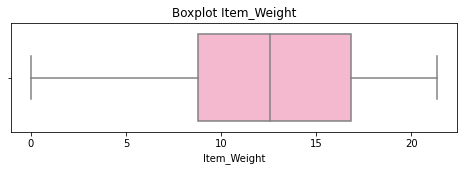

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- PENGECEKAN OUTLIER: ITEM_WEIGHT ---
Q1 = data_copy['Item_Weight'].quantile(0.25)
Q3 = data_copy['Item_Weight'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_weight = data_copy[(data_copy['Item_Weight'] < lower) | (data_copy['Item_Weight'] > upper)]

print(f"Jumlah Outlier Item_Weight: {len(outlier_weight)}")

plt.figure(figsize=(8, 2))
sns.boxplot(x=data_copy['Item_Weight'], color='#ffafcc')
plt.title('Boxplot Item_Weight')
plt.show()

# Outlier untuk Item_Visibility

In [56]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# # --- PENGECEKAN OUTLIER: ITEM_VISIBILITY ---
# Q1 = data_copy['Item_Visibility'].quantile(0.25)
# Q3 = data_copy['Item_Visibility'].quantile(0.75)
# IQR = Q3 - Q1

# lower = Q1 - 1.5 * IQR
# upper = Q3 + 1.5 * IQR

# outlier_visibility = data_copy[(data_copy['Item_Visibility'] < lower) | (data_copy['Item_Visibility'] > upper)]

# print(f"Jumlah Outlier Item_Visibility: {len(outlier_visibility)}")

# plt.figure(figsize=(8, 2))
# sns.boxplot(x=data_copy['Item_Visibility'], color='#bde0fe')
# plt.title('Boxplot Item_Visibility')
# #plt.show()
# display(data_copy['Item_Visibility']).head(5)

Ditemukan 173 baris data outlier.


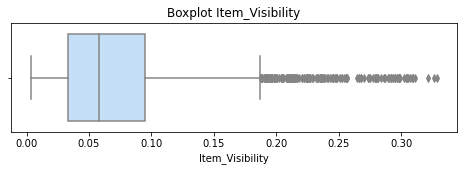

Berikut adalah tabel lengkap datanya:


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
49,FDS02,10.195,Regular,0.255395,Dairy,196.8794,OUT019,1985,Small,Tier 1,Grocery Store,780.3176
65,FDC46,17.700,Low Fat,0.195068,Snack Foods,185.4266,OUT010,1998,Small,Tier 3,Grocery Store,184.4266
83,NCL18,18.850,Low Fat,0.293418,Household,194.6136,OUT019,1985,Small,Tier 1,Grocery Store,583.2408
108,DRE60,9.395,Low Fat,0.278974,Soft Drinks,225.3720,OUT019,1985,Small,Tier 1,Grocery Store,679.1160
174,FDI32,17.700,Low Fat,0.291865,Fruits And Vegetables,115.1834,OUT010,1998,Small,Tier 3,Grocery Store,345.5502
...,...,...,...,...,...,...,...,...,...,...,...,...
8292,FDF56,16.700,Regular,0.209163,Fruits And Vegetables,179.1976,OUT019,1985,Small,Tier 1,Grocery Store,543.2928
8345,FDY28,7.470,Regular,0.266397,Frozen Foods,215.6218,OUT019,1985,Small,Tier 1,Grocery Store,641.1654
8371,DRA59,8.270,Regular,0.214125,Soft Drinks,183.9924,OUT010,1998,Small,Tier 3,Grocery Store,185.0924
8432,FDI16,14.000,Regular,0.227261,Frozen Foods,54.3640,OUT010,1998,Small,Tier 3,Grocery Store,159.7920


In [57]:
# --- MENAMPILKAN TABEL SEMUA DATA OUTLIER: ITEM_VISIBILITY ---
Q1 = data_copy['Item_Visibility'].quantile(0.25)
Q3 = data_copy['Item_Visibility'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Memasukkan semua data yang di luar pagar ke dalam variabel baru
tabel_outlier_visibility = data_copy[(data_copy['Item_Visibility'] < lower) | (data_copy['Item_Visibility'] > upper)]

# Menampilkan jumlah dan tabelnya
print(f"Ditemukan {len(tabel_outlier_visibility)} baris data outlier.")

plt.figure(figsize=(8, 2))
sns.boxplot(x=data_copy['Item_Visibility'], color='#bde0fe')
plt.title('Boxplot Item_Visibility')
plt.show()

print("Berikut adalah tabel lengkap datanya:")

# Pakai display agar muncul dalam bentuk tabel yang bisa di-scroll di notebook
display(tabel_outlier_visibility)

# Outlier untuk Item_MRP 

Jumlah Outlier Item_MRP: 0


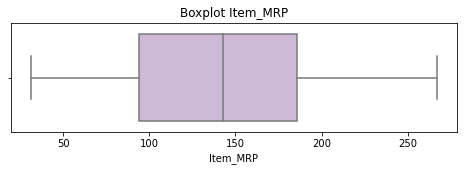

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- PENGECEKAN OUTLIER: ITEM_MRP ---
Q1 = data_copy['Item_MRP'].quantile(0.25)
Q3 = data_copy['Item_MRP'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_mrp = data_copy[(data_copy['Item_MRP'] < lower) | (data_copy['Item_MRP'] > upper)]

print(f"Jumlah Outlier Item_MRP: {len(outlier_mrp)}")

plt.figure(figsize=(8, 2))
sns.boxplot(x=data_copy['Item_MRP'], color='#cdb4db')
plt.title('Boxplot Item_MRP')
plt.show()

# Outlier untuk Item_Outlet_Sales

Jumlah Outlier Item_Outlet_Sales: 186


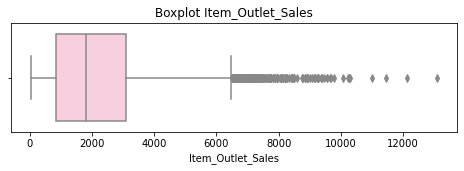

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- PENGECEKAN OUTLIER: ITEM_OUTLET_SALES ---
Q1 = data_copy['Item_Outlet_Sales'].quantile(0.25)
Q3 = data_copy['Item_Outlet_Sales'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_sales = data_copy[(data_copy['Item_Outlet_Sales'] < lower) | (data_copy['Item_Outlet_Sales'] > upper)]

print(f"Jumlah Outlier Item_Outlet_Sales: {len(outlier_sales)}")

plt.figure(figsize=(8, 2))
sns.boxplot(x=data_copy['Item_Outlet_Sales'], color='#ffc8dd')
plt.title('Boxplot Item_Outlet_Sales')
plt.show()

# 4. Data Manipulation

# Distribusi Item_Weight

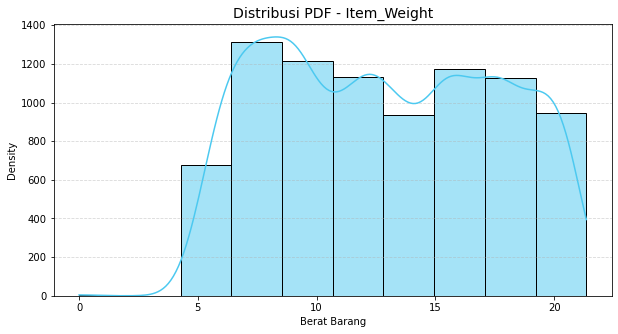

Skewness Item_Weight: 0.06


In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- DISTRIBUSI PDF: ITEM_WEIGHT ---
plt.figure(figsize=(10, 5))
sns.histplot(data_copy['Item_Weight'], kde=True, color='#4cc9f0', bins=10)

plt.title('Distribusi PDF - Item_Weight', fontsize=14)
plt.xlabel('Berat Barang')
plt.ylabel('Density')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

print(f"Skewness Item_Weight: {data_copy['Item_Weight'].skew():.2f}")

# Uji Normalitas Item_Weight

In [61]:
from scipy.stats import kstest

# Menyiapkan data
data_weight = data_copy['Item_Weight'].dropna()
data_std_weight = (data_weight - data_weight.mean()) / data_weight.std()

# Uji Kolmogorov-Smirnov
stat, p_value = kstest(data_std_weight, 'norm')

print("=== UJI KOLMOGOROV-SMIRNOV: ITEM_WEIGHT ===")
print(f"Statistik K-S: {stat:.4f}")
print(f"P-Value      : {p_value:.4f}")

if p_value > 0.05:
    print("Kesimpulan   : Data Berdistribusi NORMAL")
else:
    print("Kesimpulan   : Data TIDAK NORMAL")

=== UJI KOLMOGOROV-SMIRNOV: ITEM_WEIGHT ===
Statistik K-S: 0.0795
P-Value      : 0.0000
Kesimpulan   : Data TIDAK NORMAL


# Distribusi Item_Visibility

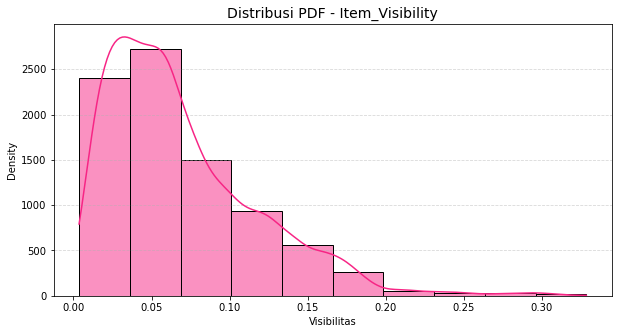

Skewness Item_Visibility: 1.31


In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- DISTRIBUSI PDF: ITEM_VISIBILITY ---
plt.figure(figsize=(10, 5))
sns.histplot(data_copy['Item_Visibility'], kde=True, color='#f72585', bins=10)

plt.title('Distribusi PDF - Item_Visibility', fontsize=14)
plt.xlabel('Visibilitas')
plt.ylabel('Density')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

print(f"Skewness Item_Visibility: {data_copy['Item_Visibility'].skew():.2f}")

# Uji Normalitas Item_Visibility

In [63]:
# Menyiapkan data
data_vis = data_copy['Item_Visibility'].dropna()
data_std_vis = (data_vis - data_vis.mean()) / data_vis.std()

# Uji Kolmogorov-Smirnov
stat, p_value = kstest(data_std_vis, 'norm')

print("=== UJI KOLMOGOROV-SMIRNOV: ITEM_VISIBILITY ===")
print(f"Statistik K-S: {stat:.4f}")
print(f"P-Value      : {p_value:.4f}")

if p_value > 0.05:
    print("Kesimpulan   : Data Berdistribusi NORMAL")
else:
    print("Kesimpulan   : Data TIDAK NORMAL")

=== UJI KOLMOGOROV-SMIRNOV: ITEM_VISIBILITY ===
Statistik K-S: 0.1145
P-Value      : 0.0000
Kesimpulan   : Data TIDAK NORMAL


# Distribusi Item_MRP

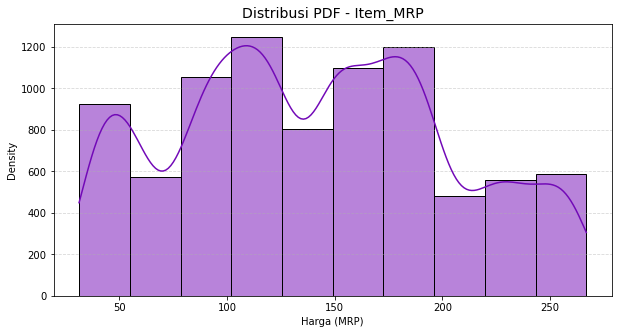

Skewness Item_MRP: 0.13


In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- DISTRIBUSI PDF: ITEM_MRP ---
plt.figure(figsize=(10, 5))
sns.histplot(data_copy['Item_MRP'], kde=True, color='#7209b7', bins=10)

plt.title('Distribusi PDF - Item_MRP', fontsize=14)
plt.xlabel('Harga (MRP)')
plt.ylabel('Density')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

print(f"Skewness Item_MRP: {data_copy['Item_MRP'].skew():.2f}")

# Uji Normalitas Item_MRP

In [65]:
# Menyiapkan data
data_mrp = data_copy['Item_MRP'].dropna()
data_std_mrp = (data_mrp - data_mrp.mean()) / data_mrp.std()

# Uji Kolmogorov-Smirnov
stat, p_value = kstest(data_std_mrp, 'norm')

print("=== UJI KOLMOGOROV-SMIRNOV: ITEM_MRP ===")
print(f"Statistik K-S: {stat:.4f}")
print(f"P-Value      : {p_value:.4f}")

if p_value > 0.05:
    print("Kesimpulan   : Data Berdistribusi NORMAL")
else:
    print("Kesimpulan   : Data TIDAK NORMAL")

=== UJI KOLMOGOROV-SMIRNOV: ITEM_MRP ===
Statistik K-S: 0.0456
P-Value      : 0.0000
Kesimpulan   : Data TIDAK NORMAL


# Distribusi Item_Outlet_Sales

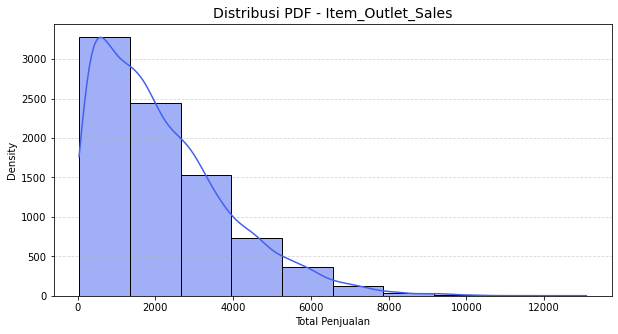

Skewness Item_Outlet_Sales: 1.18


In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- DISTRIBUSI PDF: ITEM_OUTLET_SALES ---
plt.figure(figsize=(10, 5))
sns.histplot(data_copy['Item_Outlet_Sales'], kde=True, color='#4361ee', bins=10)

plt.title('Distribusi PDF - Item_Outlet_Sales', fontsize=14)
plt.xlabel('Total Penjualan')
plt.ylabel('Density')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

print(f"Skewness Item_Outlet_Sales: {data_copy['Item_Outlet_Sales'].skew():.2f}")

# Uji Normalitas Item_Outlet_Sales

In [67]:
# Menyiapkan data
data_sales = data_copy['Item_Outlet_Sales'].dropna()
data_std_sales = (data_sales - data_sales.mean()) / data_sales.std()

# Uji Kolmogorov-Smirnov
stat, p_value = kstest(data_std_sales, 'norm')

print("=== UJI KOLMOGOROV-SMIRNOV: ITEM_OUTLET_SALES ===")
print(f"Statistik K-S: {stat:.4f}")
print(f"P-Value      : {p_value:.4f}")

if p_value > 0.05:
    print("Kesimpulan   : Data Berdistribusi NORMAL")
else:
    print("Kesimpulan   : Data TIDAK NORMAL")

=== UJI KOLMOGOROV-SMIRNOV: ITEM_OUTLET_SALES ===
Statistik K-S: 0.1041
P-Value      : 0.0000
Kesimpulan   : Data TIDAK NORMAL


# Handling Outliers dengan RobustScaler

In [68]:
from sklearn.preprocessing import RobustScaler

# Inisialisasi Scaler yang tahan banting terhadap outliers
scaler = RobustScaler()

# Scaling kolom yang ada outliers-nya
data_copy[['Item_Visibility', 'Item_Outlet_Sales']] = scaler.fit_transform(data_copy[['Item_Visibility', 'Item_Outlet_Sales']])

print("Scaling Selesai! Outliers sudah ditangani dengan RobustScaler.")

Scaling Selesai! Outliers sudah ditangani dengan RobustScaler.


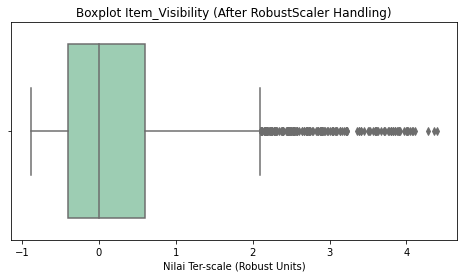

In [69]:
# Set up figure
plt.figure(figsize=(8, 4))

# Visualisasi SESUDAH Scaling (Setelah RobustScaler)
# Menggunakan warna hijau kalem (#95d5b2) biar kelihatan fresh dan profesional
sns.boxplot(x=data_copy['Item_Visibility'], color='#95d5b2')

plt.title('Boxplot Item_Visibility (After RobustScaler Handling)')
plt.xlabel('Nilai Ter-scale (Robust Units)')
plt.show()

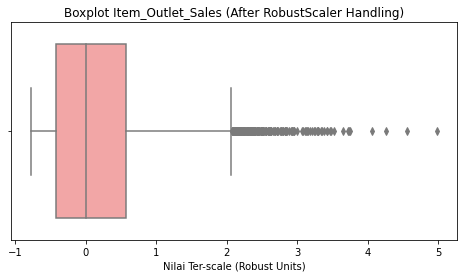

In [70]:
# Visualisasi After Handling
plt.figure(figsize=(8, 4))
sns.boxplot(x=data_copy['Item_Outlet_Sales'], color='#ff9999') # Pakai warna merah lembut biar beda dari yang hijau tadi

plt.title('Boxplot Item_Outlet_Sales (After RobustScaler Handling)')
plt.xlabel('Nilai Ter-scale (Robust Units)')
plt.show()

# Konversi Tipe Data (Type Conversion)

In [71]:
import pandas as pd

# 1. Ubah kolom teks menjadi tipe 'category'
kategori_kolom = ['Item_Fat_Content', 'Item_Type', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']
data_copy[kategori_kolom] = data_copy[kategori_kolom].astype('category')

# 2. Pastikan kolom angka benar-benar numerik
number_kolom = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Item_Outlet_Sales']
for col in number_kolom:
    data_copy[col] = pd.to_numeric(data_copy[col], errors='coerce')

# Cek apakah tipenya sudah berubah
data_copy.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,-0.682717,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,0.856094
1,DRC01,5.92,Regular,-0.630182,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,-0.595888
2,FDN15,17.50,Low Fat,-0.671127,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,0.133627
3,FDX07,19.20,Regular,0.012099,Fruits And Vegetables,182.0950,OUT010,1998,Small,Tier 3,Grocery Store,-0.468429
4,NCD19,8.93,Low Fat,-0.146632,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,-0.352717


In [72]:
data_copy.dtypes

Item_Identifier                object
Item_Weight                   float64
Item_Fat_Content             category
Item_Visibility               float64
Item_Type                    category
Item_MRP                      float64
Outlet_Identifier              object
Outlet_Establishment_Year       int64
Outlet_Size                  category
Outlet_Location_Type         category
Outlet_Type                  category
Item_Outlet_Sales             float64
dtype: object

# Melakukan Filtering & Sorting 

# Filtering berdasarkan Item_Outlet_Sales

In [73]:
# 1. Pilih ambang batas (Median agar adil 50:50)
batas_sales = data_copy['Item_Outlet_Sales'].median()

# 2. Filtering Produk yang penjualannya di atas rata-rata (High Performance)
df_filter = data_copy[data_copy['Item_Outlet_Sales'] > batas_sales]

# 3. Cek hasil sederhana
print(f"Batas Penjualan: {batas_sales}")
print(f"Jumlah produk 'High Sales': {len(df_filter)} baris")
df_filter.head()

Batas Penjualan: 0.0
Jumlah produk 'High Sales': 4258 baris


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.3,Low Fat,-0.682717,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,0.856094
2,FDN15,17.5,Low Fat,-0.671127,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,0.133627
7,FDP10,19.0,Low Fat,1.129034,Snack Foods,107.7622,OUT027,1985,Medium,Tier 3,Supermarket Type3,0.982966
9,FDU28,19.2,Regular,0.592118,Frozen Foods,187.8214,OUT017,2007,Small,Tier 2,Supermarket Type1,1.286344
11,FDA03,18.5,Regular,-0.204400,Dairy,144.1102,OUT046,1997,Small,Tier 1,Supermarket Type1,0.173275


# Sorting

In [74]:
# Sorting berdasarkan Item_Outlet_Sales (dari yang terbesar) hanya untuk pengecekan
data_sorted = data_copy.sort_values(by='Item_Outlet_Sales', ascending=False)

# Tampilkan 10 data teratas yang sudah rapi
display(data_sorted.head(10))

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
7188,NCE42,21.100,Low Fat,-0.772088,Household,234.9958,OUT027,1985,Medium,Tier 3,Supermarket Type3,4.981204
5223,FDQ19,7.350,Regular,-0.711200,Fruits And Vegetables,242.6512,OUT027,1985,Medium,Tier 3,Supermarket Type3,4.553598
1450,FDZ20,16.100,Low Fat,0.012099,Fruits And Vegetables,253.0356,OUT027,1985,Medium,Tier 3,Supermarket Type3,4.256975
4349,FDP33,18.700,Low Fat,0.500904,Snack Foods,254.2672,OUT027,1985,Medium,Tier 3,Supermarket Type3,4.057856
6541,FDI50,8.420,Regular,-0.444570,Canned,228.0352,OUT027,1985,Medium,Tier 3,Supermarket Type3,3.754772
4888,FDF39,14.850,Regular,-0.626656,Dairy,261.2910,OUT013,1987,High,Tier 3,Supermarket Type1,3.732746
1009,FDU14,17.750,Low Fat,-0.381301,Dairy,248.3750,OUT027,1985,Medium,Tier 3,Supermarket Type3,3.723935
7191,NCH18,9.300,Low Fat,-0.220966,Household,245.2802,OUT027,1985,Medium,Tier 3,Supermarket Type3,3.651689
4289,NCM05,6.825,Low Fat,0.029474,Health And Hygiene,262.5226,OUT046,1997,Small,Tier 1,Supermarket Type1,3.522467
7752,FDC17,12.150,Low Fat,-0.693472,Frozen Foods,208.9928,OUT027,1985,Medium,Tier 3,Supermarket Type3,3.477533


# Grouping 

In [75]:
# TAHAP GROUPING
# Kita ringkas data_copy berdasarkan Outlet_Type
# Melihat rata-rata penjualan per jenis toko

laporan_per_toko = (
    data_copy
    .groupby('Outlet_Type', as_index=False, observed=False)
    .agg(rata_rata_penjualan = ('Item_Outlet_Sales', 'mean'))
    .sort_values('rata_rata_penjualan', ascending=False)
)

# Tampilkan hasilnya
print("Hasil Grouping (Rata-rata Penjualan per Jenis Toko):")
laporan_per_toko

Hasil Grouping (Rata-rata Penjualan per Jenis Toko):


,Outlet_Type,rata_rata_penjualan
3,Supermarket Type3,0.837965
1,Supermarket Type1,0.230189
2,Supermarket Type2,0.088736
0,Grocery Store,-0.641584


# Membuat Kolom baru menggunakan Feature Engineering

In [76]:
# Feature Engineering: Menghitung harga per satuan berat
df_feature = data_copy.copy()
df_feature['Price_Per_Weight'] = df_feature['Item_MRP'] / df_feature['Item_Weight']

df_feature[['Item_Identifier', 'Price_Per_Weight']].head()

,Item_Identifier,Price_Per_Weight
0,FDA15,26.861204
1,DRC01,8.153581
2,FDN15,8.092457
3,FDX07,9.484115
4,NCD19,6.031512


In [77]:
# Cek nilai statistik setelah scaling
data_copy[['Item_Visibility', 'Item_Outlet_Sales']].describe()

,Item_Visibility,Item_Outlet_Sales
count,8523.000000,8523.000000
mean,0.189246,0.170688
std,0.794390,0.752741
min,-0.885524,-0.776799
25%,-0.405675,-0.423495
50%,0.000000,0.000000
75%,0.594325,0.576505
max,4.396046,4.981204


# Encoding 

# 1. Ordinal Encoding (Untuk Kolom Berjenjang)

In [78]:
# Encoding untuk Outlet_Size dan Outlet_Location_Type
# Alasan: Kedua kolom ini memiliki urutan logis (kecil ke besar / tingkat lokasi).

mapping_size = {'Small': 0, 'Medium': 1, 'High': 2}
mapping_location = {'Tier 3': 0, 'Tier 2': 1, 'Tier 1': 2}

df_feature['Outlet_Size_Encoded'] = df_feature['Outlet_Size'].map(mapping_size)
df_feature['Outlet_Location_Type_Encoded'] = df_feature['Outlet_Location_Type'].map(mapping_location)

print("Ordinal Encoding Selesai!")
display(df_feature[['Outlet_Size', 'Outlet_Size_Encoded', 'Outlet_Location_Type', 'Outlet_Location_Type_Encoded']].head())

Ordinal Encoding Selesai!


,Outlet_Size,Outlet_Size_Encoded,Outlet_Location_Type,Outlet_Location_Type_Encoded
0,Medium,1,Tier 1,2
1,Medium,1,Tier 3,0
2,Medium,1,Tier 1,2
3,Small,0,Tier 3,0
4,High,2,Tier 3,0


# 2. Label Encoding (Untuk Kolom Biner/2 Pilihan)

In [79]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# Encoding untuk Item_Fat_Content
# Alasan: Hanya ada dua kategori utama (Low Fat & Regular), jadi cukup diubah jadi 0 dan 1.
df_feature['Item_Fat_Content_Encoded'] = le.fit_transform(df_feature['Item_Fat_Content'])

print("Label Encoding Selesai!")
display(df_feature[['Item_Fat_Content', 'Item_Fat_Content_Encoded']].head())

Label Encoding Selesai!


,Item_Fat_Content,Item_Fat_Content_Encoded
0,Low Fat,0
1,Regular,1
2,Low Fat,0
3,Regular,1
4,Low Fat,0


# 3. One-Hot Encoding (Untuk Kolom Setara/Nominal)

In [80]:
# One-Hot Encoding untuk Item_Type dan Outlet_Type
# Alasan: Jenis barang dan jenis toko tidak memiliki urutan (Daging tidak lebih tinggi dari Sayur).

df_final = pd.get_dummies(df_feature, columns=['Item_Type', 'Outlet_Type'], prefix=['Item', 'Outlet'], dtype=int)

print("One-Hot Encoding Selesai!")

# Menampilkan beberapa kolom hasil encoding
display(df_final.filter(like='Outlet_').head())

One-Hot Encoding Selesai!


,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Item_Outlet_Sales,Outlet_Size_Encoded,Outlet_Location_Type_Encoded,Outlet_Grocery Store,Outlet_Supermarket Type1,Outlet_Supermarket Type2,Outlet_Supermarket Type3
0,OUT049,1999,Medium,Tier 1,0.856094,1,2,0,1,0,0
1,OUT018,2009,Medium,Tier 3,-0.595888,1,0,0,0,1,0
2,OUT049,1999,Medium,Tier 1,0.133627,1,2,0,1,0,0
3,OUT010,1998,Small,Tier 3,-0.468429,0,0,1,0,0,0
4,OUT013,1987,High,Tier 3,-0.352717,2,0,0,1,0,0


# Analisis Statistik

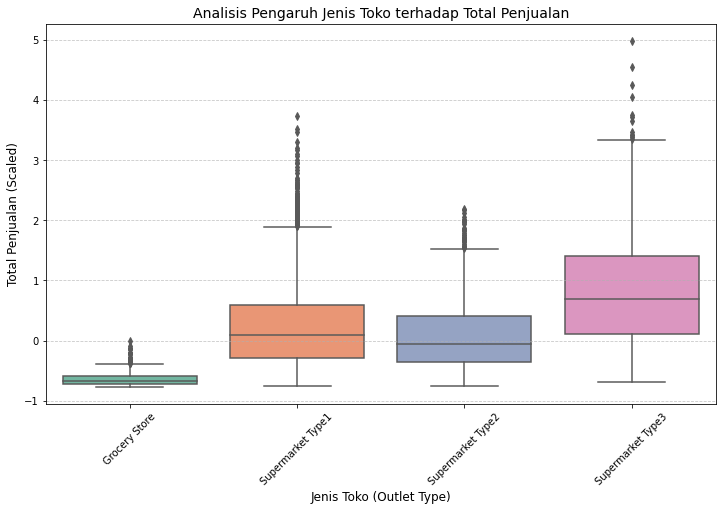

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))

# Membuat Boxplot untuk membandingkan penjualan per jenis toko
sns.boxplot(data=data_copy, x='Outlet_Type', y='Item_Outlet_Sales', palette='Set2')

plt.title('Analisis Pengaruh Jenis Toko terhadap Total Penjualan', fontsize=14)
plt.xlabel('Jenis Toko (Outlet Type)', fontsize=12)
plt.ylabel('Total Penjualan (Scaled)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# Analisis PMF

In [82]:
# Menghitung PMF untuk kombinasi Jenis Toko (Outlet Type) dan Ukuran Toko (Outlet Size)
# Ini jauh lebih relevan dengan judul "Pengaruh Jenis Toko"
pmf_data = data_copy.groupby(['Outlet_Type', 'Outlet_Size'], observed=False).size() / len(data_copy)
pmf_data = pmf_data.reset_index(name='Probability')

print("=== Tabel PMF Kombinasi Jenis Toko & Ukuran Toko ===")
display(pmf_data)

# # Visualisasi Heatmap PMF yang relevan
# import seaborn as sns
# import matplotlib.pyplot as plt

# plt.figure(figsize=(10, 6))
# pmf_pivot = pmf_data.pivot(index='Outlet_Type', columns='Outlet_Size', values='Probability')
# sns.heatmap(pmf_pivot, annot=True, cmap='YlGnBu', fmt='.4f')
# plt.title('Heatmap PMF: Peluang Distribusi Jenis & Ukuran Toko')
# plt.show()

=== Tabel PMF Kombinasi Jenis Toko & Ukuran Toko ===


,Outlet_Type,Outlet_Size,Probability
0,Grocery Store,High,0.000000
1,Grocery Store,Medium,0.000000
2,Grocery Store,Small,0.127068
3,Supermarket Type1,High,0.109351
4,Supermarket Type1,Medium,0.109117
5,Supermarket Type1,Small,0.435879
6,Supermarket Type2,High,0.000000
7,Supermarket Type2,Medium,0.108882
8,Supermarket Type2,Small,0.000000
9,Supermarket Type3,High,0.000000


# Uji statistik: Kruskal-wallis test

In [83]:
from scipy import stats

# 1. Menyiapkan grup data penjualan berdasarkan Jenis Toko
# Kita ambil kolom penjualan untuk tiap kategori toko
groups = []
for outlet_type in data_copy["Outlet_Type"].unique():
    # Mengambil data penjualan untuk masing-masing tipe dan hapus nilai kosong jika ada
    sales_data = data_copy[data_copy["Outlet_Type"] == outlet_type]["Item_Outlet_Sales"].dropna()
    groups.append(sales_data)

# 2. Eksekusi Kruskal-Wallis Test
h_stat, p_val = stats.kruskal(*groups)

print("=== Hasil Uji Statistik: Kruskal-Wallis Test ===")
print(f"H-statistic : {h_stat:.4f}")
print(f"p-value     : {p_val:.4f}")

# 3. Batas Signifikansi
alpha = 0.05

print("\nKesimpulan Akhir:")
if p_val < alpha:
    print("Tolak H0: Terdapat perbedaan distribusi penjualan yang signifikan antar jenis toko.")
else:
    print("Gagal Tolak H0: Tidak ada perbedaan distribusi penjualan yang signifikan antar jenis toko.")

=== Hasil Uji Statistik: Kruskal-Wallis Test ===
H-statistic : 2803.3609
p-value     : 0.0000

Kesimpulan Akhir:
Tolak H0: Terdapat perbedaan distribusi penjualan yang signifikan antar jenis toko.


# Output Final Dataset

# data sebelum siap dianalisis

In [84]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [86]:
df.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

# data sesudah siap dianalisis

In [87]:
data_copy.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,-0.682717,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,0.856094
1,DRC01,5.92,Regular,-0.630182,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,-0.595888
2,FDN15,17.50,Low Fat,-0.671127,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,0.133627
3,FDX07,19.20,Regular,0.012099,Fruits And Vegetables,182.0950,OUT010,1998,Small,Tier 3,Grocery Store,-0.468429
4,NCD19,8.93,Low Fat,-0.146632,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,-0.352717


In [88]:
df_feature.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Price_Per_Weight,Outlet_Size_Encoded,Outlet_Location_Type_Encoded,Item_Fat_Content_Encoded
0,FDA15,9.30,Low Fat,-0.682717,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,0.856094,26.861204,1,2,0
1,DRC01,5.92,Regular,-0.630182,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,-0.595888,8.153581,1,0,1
2,FDN15,17.50,Low Fat,-0.671127,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,0.133627,8.092457,1,2,0
3,FDX07,19.20,Regular,0.012099,Fruits And Vegetables,182.0950,OUT010,1998,Small,Tier 3,Grocery Store,-0.468429,9.484115,0,0,1
4,NCD19,8.93,Low Fat,-0.146632,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,-0.352717,6.031512,2,0,0


In [89]:
data_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   Item_Identifier            8523 non-null   object  
 1   Item_Weight                8523 non-null   float64 
 2   Item_Fat_Content           8523 non-null   category
 3   Item_Visibility            8523 non-null   float64 
 4   Item_Type                  8523 non-null   category
 5   Item_MRP                   8523 non-null   float64 
 6   Outlet_Identifier          8523 non-null   object  
 7   Outlet_Establishment_Year  8523 non-null   int64   
 8   Outlet_Size                8523 non-null   category
 9   Outlet_Location_Type       8523 non-null   category
 10  Outlet_Type                8523 non-null   category
 11  Item_Outlet_Sales          8523 non-null   float64 
dtypes: category(5), float64(4), int64(1), object(2)
memory usage: 509.1+ KB


In [90]:
df_feature.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   Item_Identifier               8523 non-null   object  
 1   Item_Weight                   8523 non-null   float64 
 2   Item_Fat_Content              8523 non-null   category
 3   Item_Visibility               8523 non-null   float64 
 4   Item_Type                     8523 non-null   category
 5   Item_MRP                      8523 non-null   float64 
 6   Outlet_Identifier             8523 non-null   object  
 7   Outlet_Establishment_Year     8523 non-null   int64   
 8   Outlet_Size                   8523 non-null   category
 9   Outlet_Location_Type          8523 non-null   category
 10  Outlet_Type                   8523 non-null   category
 11  Item_Outlet_Sales             8523 non-null   float64 
 12  Price_Per_Weight              8523 non-null   fl

In [91]:
# Cek apakah kolom baru sudah masuk dalam daftar kolom
print(df_feature.columns)

# Atau tampilkan hanya kolom baru beserta ID-nya saja
display(df_feature[['Item_Identifier', 'Price_Per_Weight']].head())

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales', 'Price_Per_Weight',
       'Outlet_Size_Encoded', 'Outlet_Location_Type_Encoded',
       'Item_Fat_Content_Encoded'],
      dtype='object')


,Item_Identifier,Price_Per_Weight
0,FDA15,26.861204
1,DRC01,8.153581
2,FDN15,8.092457
3,FDX07,9.484115
4,NCD19,6.031512


In [92]:
data_copy.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64